In [3]:
from src.train import train_model
from src.extractor import run_full_extraction_pipeline
from src.run_cali import run_cali
from src.evaluation import compare_methods

seed = 0

train_model(seed=seed)
run_full_extraction_pipeline(seed=seed)
run_cali(seed=seed)
metrics_table, detailed_results = compare_methods(seed=seed)

Number of classes: 10
[SKIP TRAINING] cifar10 | seed 0 - checkpoint already exists.
Number of classes: 10
Extracting features for architecture: ResNet
Extracting features for architecture: ResNet
------------------------------
ResNet feature extraction results:
Training Accuracy: 93.03%
Eval Accuracy:     90.73%
------------------------------
Features saved to: ./results/features_cifar10_resnet/seed0
Loading raw data from: ./results/features_cifar10_resnet/seed0
Available layers for ResNet: layer4

Processing layer: layer4
Extracting tensors for layer: layer4
Input Dim: 512 | Train Samples: 50000
Training CWAE (40 epochs)...
=== Starting multi-class training (10 models) ===

Processing class 0...
 Feature shape: torch.Size([5273, 512]), Flags: torch.Size([5273])
  -> Samples: 5273 (Correct: 4862, Errors: 411)
--- CWAE training start (Dim 512 -> 10) | LR schedule: Cosine ---
Ep [5/40] | learning_rate: 9.8e-04 | Loss: 0.6134 | Rec: 0.1687 | CW: 0.0423 | Radius: 0.2121
Ep [10/40] | learni

KDE-Trust scoring: 100%|██████████| 10000/10000 [00:09<00:00, 1109.81it/s]


--- Metrics cifar10_resnet | layer4 ---
(0.9099602160160587, 0.4153182308522114, 0.9872677579614599, 0.5688751120424087, 0.6100872084829319, 16.149315970600593, 11.708751155379604)
--- Evaluation Pipeline: cifar10 | resnet | Seed 0 ---
Computing MC Dropout (N=50) for cifar10...


/home/nathan/CALI/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Number of classes: 10


MC Dropout: 100%|██████████| 79/79 [01:27<00:00,  1.11s/it]


MC Dropout computed and saved: ./results/mc_dropout_cache/mc_cifar10_resnet_seed0_n50.npz

--- Confidence Metrics Comparison ---
                   WAE_Cali  Softmax  TrustScore  EnergyScore  MC_Dropout
AUROC                0.9100   0.9016      0.9250       0.8322      0.8941
FPR@95TPR (lower)    0.4153   0.5318      0.4293       0.7023      0.6307
AUPR                 0.9873   0.9886      0.9916       0.9787      0.9883
AUPR-error           0.5689   0.4754      0.5544       0.3196      0.4021
Wasserstein          0.6101   0.3121      0.1242       0.1552      0.3060
AURC (lower)        16.1493  14.9616     12.2255      24.2332     15.1015
e-AURC (lower)      11.7088  10.5210      7.7849      19.7926     10.8534


In [ ]:
from src.evaluation import compare_methods
metrics_table, detailed_results = compare_methods(seed=2)

from src.visualisations import plot_publication_separation
plot_publication_separation(detailed_results, methods_to_plot=['score_cali', 'score_softmax', 'score_mcdropout', 'score_trust', 'score_energy'])

In [2]:
from src.evaluation import save_failure_threshold

save_failure_threshold(seed=0)

Processing Seed 0...
--- Evaluation Pipeline: cifar10 | resnet | Seed 0 ---
Loading MC Dropout from cache: ./results/mc_dropout_cache/mc_cifar10_resnet_seed0_n50.npz
Results for seed 0 saved to ./results/failure_threshold/cifar10_resnet_seed0_results.csv


True

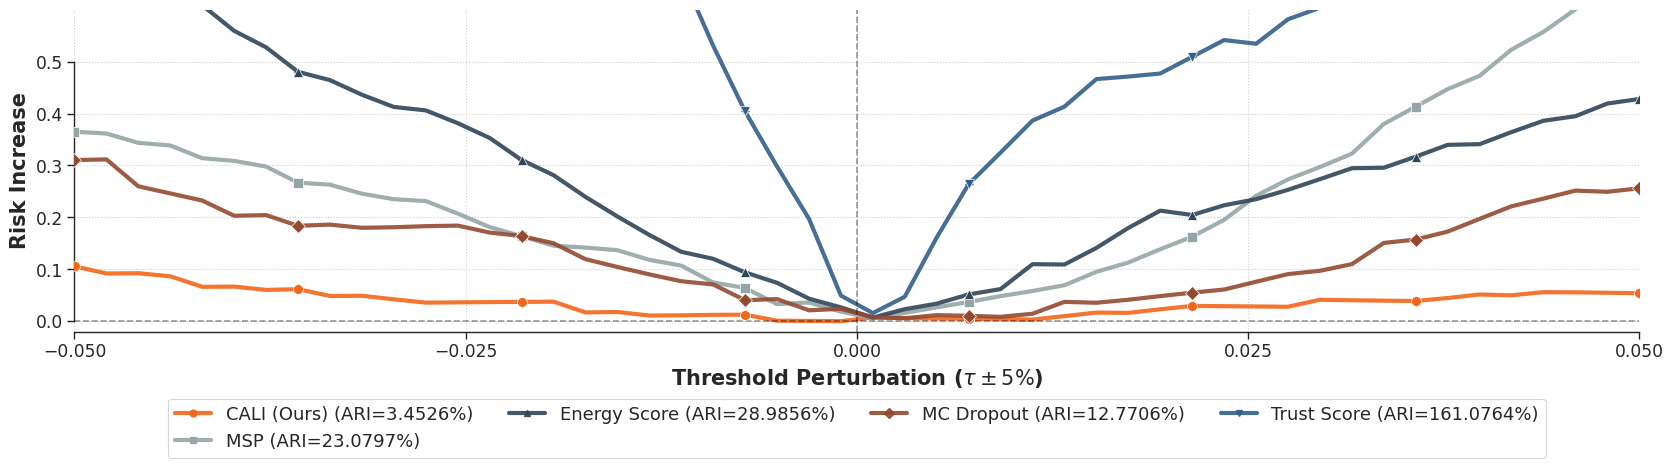

In [1]:
from src.visualisations import plot_operational_stability_failure

plot_operational_stability_failure(seed=0, delta=0.05)